<a href="https://colab.research.google.com/github/Keshusrm/DeepLearning/blob/main/lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Lab: Comparative Study and Implementation of Optimization Algorithms

## SGD, SGD with Momentum, RMSprop and Adam

### Objective

In this lab, we will train the **same neural network** using four optimization algorithms:

1. Stochastic Gradient Descent (SGD)
2. SGD with Momentum
3. RMSprop
4. Adam

We will compare them using:

- Training loss
- Test loss
- Test accuracy
- Convergence speed
- Number of epochs required to reach a target accuracy
- Effect of learning rate
- Effect of mini-batch size

> **Important:** The same dataset, network architecture, train/test split and initial model weights are used for every optimizer so that the comparison is meaningful.



## Learning Outcomes

After completing this experiment, you should be able to:

- Explain the role of an optimizer in neural-network training.
- Implement a neural network training loop.
- Understand the working principle of SGD, Momentum, RMSprop and Adam.
- Compare optimization algorithms experimentally.
- Interpret loss and accuracy curves.
- Explain why adaptive optimizers can converge differently from plain SGD.
- Analyze the effect of learning rate and mini-batch size.



# 1. Theory

Let $\theta$ represent a model parameter and let $L$ be the loss function.

The gradient of the loss with respect to the parameter is

$$
g_t = \nabla_{\theta} L(\theta_t)
$$

where:

- $g_t$ = gradient at iteration $t$
- $\theta_t$ = parameter value at iteration $t$
- $\eta$ = learning rate

## 1.1 SGD

SGD updates the parameters using the gradient calculated from the current mini-batch:

$$
\theta_{t+1} = \theta_t - \eta g_t
$$

SGD is simple, but its updates can be noisy.

## 1.2 SGD with Momentum

Momentum keeps a running velocity based on previous gradients:

$$
v_t = \beta v_{t-1} + g_t
$$

The parameter update is

$$
\theta_{t+1} = \theta_t - \eta v_t
$$

where $\beta$ controls the contribution from the previous velocity.

## 1.3 RMSprop

RMSprop maintains an exponentially weighted average of squared gradients:

$$
s_t = \beta s_{t-1} + (1-\beta)g_t^2
$$

The parameter update becomes

$$
\theta_{t+1}
=
\theta_t
-
\frac{\eta}{\sqrt{s_t}+\epsilon}g_t
$$

where $\epsilon$ is a small positive number used for numerical stability.

## 1.4 Adam

Adam combines a first-moment estimate, similar to Momentum, with a second-moment estimate, similar to RMSprop.

First moment:

$$
m_t = \beta_1m_{t-1} + (1-\beta_1)g_t
$$

Second moment:

$$
v_t = \beta_2v_{t-1} + (1-\beta_2)g_t^2
$$

Because $m_t$ and $v_t$ are initialized at zero, Adam applies bias correction:

$$
\hat{m}_t = \frac{m_t}{1-\beta_1^t}
$$

$$
\hat{v}_t = \frac{v_t}{1-\beta_2^t}
$$

Finally, Adam updates the parameter using

$$
\theta_{t+1}
=
\theta_t
-
\eta
\frac{\hat{m}_t}
{\sqrt{\hat{v}_t}+\epsilon}
$$


# 2. Import Libraries

In [1]:

import time
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("PyTorch version:", torch.__version__)


PyTorch version: 2.11.0+cpu


In [2]:

# Reproducibility

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)


Device: cpu



# 3. Dataset: Digits Classification

We use the **scikit-learn Digits dataset** instead of a simple two-class dataset.

The dataset contains handwritten digits from **0 to 9**, giving us:

- 1,797 samples
- 64 input features per image
- $8 \times 8$ grayscale images
- **10 output classes**

This is a substantially more useful classification problem for comparing optimizers.


In [3]:

digits = load_digits()

X = digits.data.astype(np.float32)
y = digits.target.astype(np.int64)

print("Number of samples :", X.shape[0])
print("Number of features:", X.shape[1])
print("Number of classes :", len(np.unique(y)))
print("Classes           :", np.unique(y))


Number of samples : 1797
Number of features: 64
Number of classes : 10
Classes           : [0 1 2 3 4 5 6 7 8 9]


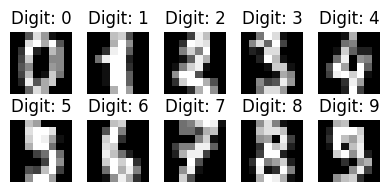

In [4]:

# Visualize representative samples

fig, axes = plt.subplots(2, 5, figsize=(4, 2))

for ax, image, label in zip(
    axes.ravel(),
    digits.images[:10],
    digits.target[:10]
):
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Digit: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()


In [5]:

# Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

# Standardize the input features using only the training set.
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))


Training samples: 1437
Testing samples : 360


In [6]:

# Mini-batch size used in the main experiment

BATCH_SIZE = 32

train_dataset = TensorDataset(
    torch.tensor(X_train),
    torch.tensor(y_train)
)

test_dataset = TensorDataset(
    torch.tensor(X_test),
    torch.tensor(y_test)
)

# Fixed generator makes the DataLoader shuffling reproducible.
generator = torch.Generator()
generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=generator
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False
)

print("Mini-batch size:", BATCH_SIZE)


Mini-batch size: 32



# 4. Neural Network

The same network will be used for all four optimizers.

Architecture:

$$
64 \rightarrow 128 \rightarrow 64 \rightarrow 10
$$

The final layer has 10 outputs because the dataset contains 10 classes.


In [7]:

class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.network(x)


def create_model():
    return SimpleNN().to(device)


criterion = nn.CrossEntropyLoss()

model = create_model()
print(model)


SimpleNN(
  (network): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)



# 5. Optimizer Configuration

For the main comparison, we use commonly used learning-rate settings:

| Optimizer | Learning Rate | Important Parameter |
|---|---:|---:|
| SGD | 0.01 | — |
| SGD + Momentum | 0.01 | $\beta = 0.9$ |
| RMSprop | 0.001 | $\beta = 0.99$ |
| Adam | 0.001 | $\beta_1=0.9,\ \beta_2=0.999$ |

These are **experimental settings**, not universal best values. Later in the notebook, students will change them and observe the effect.


In [8]:

optimizer_config = {
    "SGD": {
        "lr": 0.01
    },

    "SGD + Momentum": {
        "lr": 0.01,
        "momentum": 0.9
    },

    "RMSprop": {
        "lr": 0.001,
        "alpha": 0.99
    },

    "Adam": {
        "lr": 0.001,
        "betas": (0.9, 0.999)
    }
}

print(pd.DataFrame(optimizer_config).T)


                   lr momentum alpha         betas
SGD              0.01      NaN   NaN           NaN
SGD + Momentum   0.01      0.9   NaN           NaN
RMSprop         0.001      NaN  0.99           NaN
Adam            0.001      NaN   NaN  (0.9, 0.999)


In [9]:

def create_optimizer(name, model):
    config = optimizer_config[name]

    if name == "SGD":
        return torch.optim.SGD(
            model.parameters(),
            lr=config["lr"]
        )

    elif name == "SGD + Momentum":
        return torch.optim.SGD(
            model.parameters(),
            lr=config["lr"],
            momentum=config["momentum"]
        )

    elif name == "RMSprop":
        return torch.optim.RMSprop(
            model.parameters(),
            lr=config["lr"],
            alpha=config["alpha"]
        )

    elif name == "Adam":
        return torch.optim.Adam(
            model.parameters(),
            lr=config["lr"],
            betas=config["betas"]
        )

    raise ValueError("Unknown optimizer")


# 6. Training and Evaluation Functions

In [10]:

def evaluate(model, loader):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            total_loss += loss.item() * len(X_batch)

            predictions = torch.argmax(logits, dim=1)
            correct += (predictions == y_batch).sum().item()
            total += len(X_batch)

    average_loss = total_loss / total
    accuracy = correct / total

    return average_loss, accuracy


In [11]:

def train_model(optimizer_name, epochs=50, verbose=True):
    # Create identical initial weights for every optimizer.
    torch.manual_seed(123)

    model = create_model()
    optimizer = create_optimizer(optimizer_name, model)

    train_losses = []
    test_losses = []
    test_accuracies = []

    start_time = time.perf_counter()

    for epoch in range(epochs):
        model.train()

        running_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            # 1. Clear old gradients
            optimizer.zero_grad()

            # 2. Forward pass
            logits = model(X_batch)

            # 3. Calculate loss
            loss = criterion(logits, y_batch)

            # 4. Backpropagation
            loss.backward()

            # 5. Optimizer update
            optimizer.step()

            running_loss += loss.item() * len(X_batch)

        train_loss = running_loss / len(train_dataset)
        test_loss, test_accuracy = evaluate(model, test_loader)

        train_losses.append(train_loss)
        test_losses.append(test_loss)
        test_accuracies.append(test_accuracy)

        if verbose and (epoch == 0 or (epoch + 1) % 10 == 0):
            print(
                f"Epoch {epoch + 1:2d}/{epochs} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Test Loss: {test_loss:.4f} | "
                f"Test Accuracy: {test_accuracy * 100:.2f}%"
            )

    elapsed_time = time.perf_counter() - start_time

    return {
        "model": model,
        "train_loss": train_losses,
        "test_loss": test_losses,
        "test_accuracy": test_accuracies,
        "time": elapsed_time
    }



# 7. Main Experiment

We now train the same neural network using all four optimizers.

Use **50 epochs** initially. Do not change the model architecture between experiments.


In [15]:

EPOCHS = 30
results = {}

for optimizer_name in optimizer_config:
    print("=" * 70)
    print(f"Training with {optimizer_name}")

    results[optimizer_name] = train_model(
        optimizer_name,
        epochs=EPOCHS,
        verbose=True
    )

print("=" * 70)
print("All experiments completed.")


Training with SGD
Epoch  1/30 | Train Loss: 2.2664 | Test Loss: 2.2442 | Test Accuracy: 20.28%
Epoch 10/30 | Train Loss: 1.3392 | Test Loss: 1.2819 | Test Accuracy: 75.28%
Epoch 20/30 | Train Loss: 0.4369 | Test Loss: 0.4318 | Test Accuracy: 90.28%
Epoch 30/30 | Train Loss: 0.2122 | Test Loss: 0.2320 | Test Accuracy: 95.28%
Training with SGD + Momentum
Epoch  1/30 | Train Loss: 2.1209 | Test Loss: 1.7816 | Test Accuracy: 65.83%
Epoch 10/30 | Train Loss: 0.0382 | Test Loss: 0.1166 | Test Accuracy: 98.06%
Epoch 20/30 | Train Loss: 0.0108 | Test Loss: 0.1183 | Test Accuracy: 97.78%
Epoch 30/30 | Train Loss: 0.0052 | Test Loss: 0.1237 | Test Accuracy: 97.50%
Training with RMSprop
Epoch  1/30 | Train Loss: 0.6642 | Test Loss: 0.2236 | Test Accuracy: 95.28%
Epoch 10/30 | Train Loss: 0.0078 | Test Loss: 0.0978 | Test Accuracy: 97.78%
Epoch 20/30 | Train Loss: 0.0005 | Test Loss: 0.1100 | Test Accuracy: 98.06%
Epoch 30/30 | Train Loss: 0.0000 | Test Loss: 0.1229 | Test Accuracy: 98.33%
Trainin

# 8. Compare Training Loss

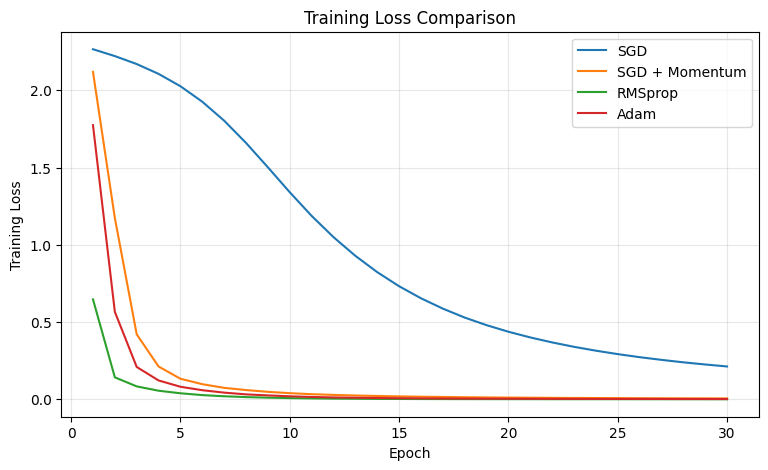

In [14]:

plt.figure(figsize=(9, 5))

for name, result in results.items():
    plt.plot(
        range(1, EPOCHS + 1),
        result["train_loss"],
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# 9. Compare Test Loss

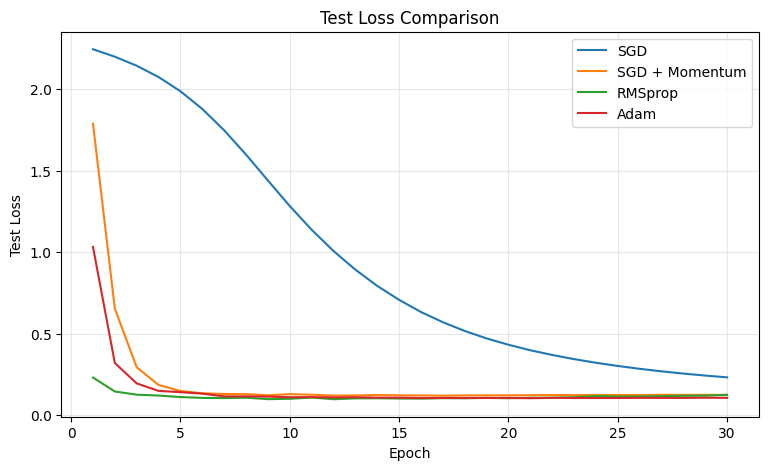

In [ ]:

plt.figure(figsize=(9, 5))

for name, result in results.items():
    plt.plot(
        range(1, EPOCHS + 1),
        result["test_loss"],
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Test Loss")
plt.title("Test Loss Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# 10. Compare Test Accuracy

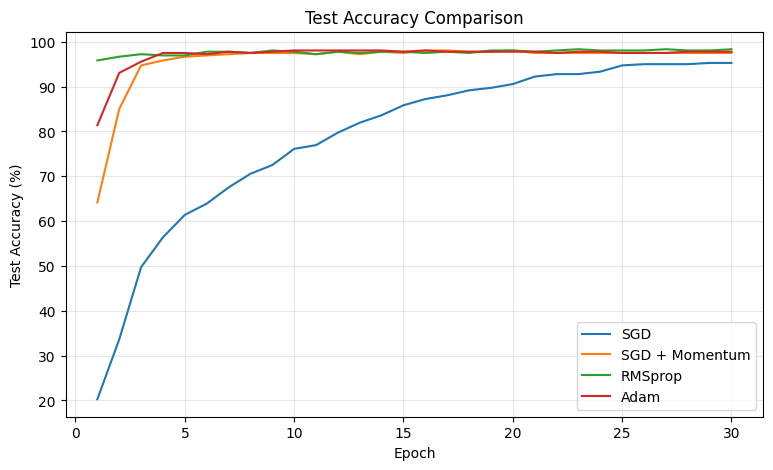

In [ ]:

plt.figure(figsize=(9, 5))

for name, result in results.items():
    accuracy = np.array(result["test_accuracy"]) * 100

    plt.plot(
        range(1, EPOCHS + 1),
        accuracy,
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy (%)")
plt.title("Test Accuracy Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# 11. Numerical Comparison

In [ ]:

summary = []

for name, result in results.items():
    summary.append({
        "Optimizer": name,
        "Final Train Loss": result["train_loss"][-1],
        "Final Test Loss": result["test_loss"][-1],
        "Final Test Accuracy (%)": result["test_accuracy"][-1] * 100,
        "Training Time (s)": result["time"]
    })

summary_df = pd.DataFrame(summary)

summary_df.sort_values(
    by="Final Test Accuracy (%)",
    ascending=False
).reset_index(drop=True)


,Optimizer,Final Train Loss,Final Test Loss,Final Test Accuracy (%),Training Time (s)
0,RMSprop,0.000035,0.124467,98.333333,0.483968
1,Adam,0.001184,0.105998,97.777778,0.514748
2,SGD + Momentum,0.005230,0.124361,97.500000,0.420493
3,SGD,0.211971,0.231700,95.277778,0.428844



# 12. Convergence Speed

We will define convergence speed experimentally as the first epoch at which the model reaches a chosen test-accuracy threshold.

Here we use **95% test accuracy**.

If an optimizer does not reach the threshold within the selected number of epochs, it will be reported as **Not reached**.

> The threshold is only an experimental measure for this lab. It is not a universal definition of convergence.


In [ ]:

TARGET_ACCURACY = 95.0

convergence = []

for name, result in results.items():
    accuracy = np.array(result["test_accuracy"]) * 100

    reached = np.where(accuracy >= TARGET_ACCURACY)[0]

    if len(reached) > 0:
        first_epoch = int(reached[0] + 1)
    else:
        first_epoch = None

    convergence.append({
        "Optimizer": name,
        f"First Epoch >= {TARGET_ACCURACY:.0f}%": (
            first_epoch if first_epoch is not None else "Not reached"
        ),
        "Final Accuracy (%)": accuracy[-1]
    })

convergence_df = pd.DataFrame(convergence)
convergence_df


,Optimizer,First Epoch >= 95%,Final Accuracy (%)
0,SGD,26,95.277778
1,SGD + Momentum,4,97.500000
2,RMSprop,1,98.333333
3,Adam,3,97.777778


# 13. Early Training Comparison

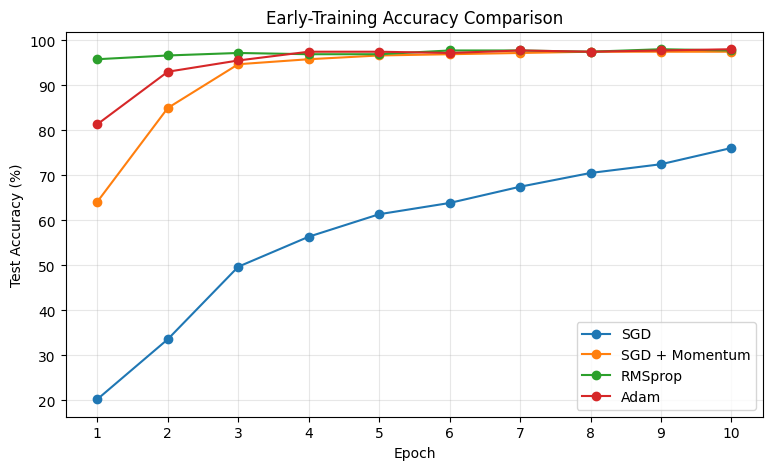

In [ ]:

# Focus on the first 10 epochs to make early convergence differences easier to see.

first_n_epochs = min(10, EPOCHS)

plt.figure(figsize=(9, 5))

for name, result in results.items():
    accuracy = np.array(result["test_accuracy"][:first_n_epochs]) * 100

    plt.plot(
        range(1, first_n_epochs + 1),
        accuracy,
        marker="o",
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy (%)")
plt.title("Early-Training Accuracy Comparison")
plt.xticks(range(1, first_n_epochs + 1))
plt.legend()
plt.grid(alpha=0.3)
plt.show()



# 14. Optimizer Update Demonstration

The previous experiment used PyTorch's built-in optimizer implementations.

The following small numerical demonstration shows the **parameter-update equations** directly for a single parameter. This helps connect the theory with the implementation.

Assume:

$$
\theta_0 = 2.0,\qquad g_1 = 0.5,\qquad \eta = 0.1
$$

Students can modify the values and observe how the update produced by each algorithm changes.


In [ ]:

theta = 2.0
gradient = 0.5
learning_rate = 0.1

# SGD
theta_sgd = theta - learning_rate * gradient

print("Initial theta :", theta)
print("Gradient      :", gradient)
print("SGD theta     :", theta_sgd)


Initial theta : 2.0
Gradient      : 0.5
SGD theta     : 1.95


In [ ]:

# SGD with Momentum
beta = 0.9
v_previous = 0.0

v = beta * v_previous + gradient
theta_momentum = theta - learning_rate * v

print("Velocity       :", v)
print("Updated theta  :", theta_momentum)


Velocity       : 0.5
Updated theta  : 1.95


In [ ]:

# RMSprop
beta = 0.99
epsilon = 1e-8
s_previous = 0.0

s = beta * s_previous + (1 - beta) * gradient**2

theta_rmsprop = (
    theta
    - learning_rate * gradient / (np.sqrt(s) + epsilon)
)

print("Squared-gradient average:", s)
print("Updated theta           :", theta_rmsprop)


Squared-gradient average: 0.0025000000000000022
Updated theta           : 1.0000001999999606


In [ ]:

# Adam
beta1 = 0.9
beta2 = 0.999
epsilon = 1e-8

m_previous = 0.0
v_previous = 0.0
t = 1

m = beta1 * m_previous + (1 - beta1) * gradient
v = beta2 * v_previous + (1 - beta2) * gradient**2

m_hat = m / (1 - beta1**t)
v_hat = v / (1 - beta2**t)

theta_adam = (
    theta
    - learning_rate * m_hat / (np.sqrt(v_hat) + epsilon)
)

print("m              :", m)
print("v              :", v)
print("Bias-corrected m:", m_hat)
print("Bias-corrected v:", v_hat)
print("Updated theta   :", theta_adam)


m              : 0.04999999999999999
v              : 0.0002500000000000002
Bias-corrected m: 0.5
Bias-corrected v: 0.25
Updated theta   : 1.900000002



# 15. Experiment: Effect of Learning Rate

The learning rate strongly affects optimization.

Try changing the learning rate for one optimizer at a time.

Suggested values:

### SGD
- 0.001
- 0.01
- 0.05
- 0.1

### SGD with Momentum
- 0.001
- 0.01
- 0.05
- 0.1

### RMSprop
- 0.0001
- 0.001
- 0.005
- 0.01

### Adam
- 0.0001
- 0.001
- 0.005
- 0.01

Observe:

- Does the loss decrease faster?
- Does the model become unstable?
- Does the final accuracy change?


In [ ]:

# Example: compare several learning rates for Adam

learning_rates = [0.0001, 0.001, 0.005, 0.01]
adam_lr_results = {}

original_config = optimizer_config["Adam"].copy()

for lr in learning_rates:
    optimizer_config["Adam"]["lr"] = lr

    adam_lr_results[lr] = train_model(
        "Adam",
        epochs=30,
        verbose=False
    )

optimizer_config["Adam"] = original_config

for lr, result in adam_lr_results.items():
    print(
        f"Adam lr={lr:<7} | "
        f"Final Test Accuracy = {result['test_accuracy'][-1] * 100:.2f}% | "
        f"Final Test Loss = {result['test_loss'][-1]:.4f}"
    )


Adam lr=0.0001  | Final Test Accuracy = 96.11% | Final Test Loss = 0.1803
Adam lr=0.001   | Final Test Accuracy = 97.78% | Final Test Loss = 0.1077
Adam lr=0.005   | Final Test Accuracy = 97.50% | Final Test Loss = 0.1448
Adam lr=0.01    | Final Test Accuracy = 96.11% | Final Test Loss = 0.5488


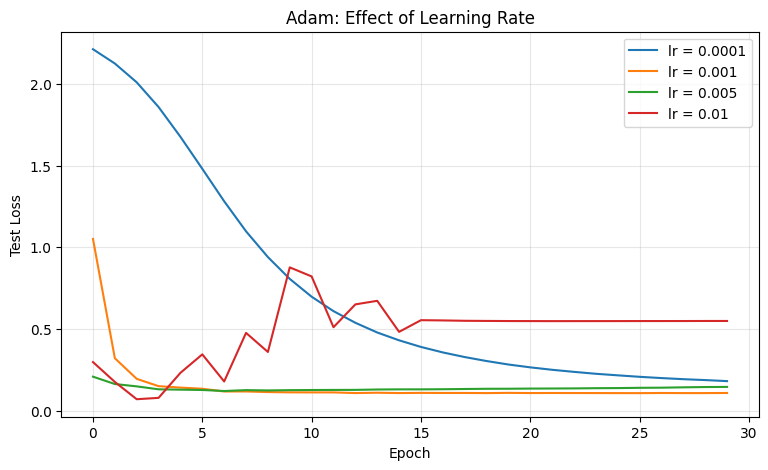

In [ ]:

plt.figure(figsize=(9, 5))

for lr, result in adam_lr_results.items():
    plt.plot(
        result["test_loss"],
        label=f"lr = {lr}"
    )

plt.xlabel("Epoch")
plt.ylabel("Test Loss")
plt.title("Adam: Effect of Learning Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



# 16. Experiment: Effect of Mini-Batch Size

Mini-batch size also affects stochastic optimization.

Try:

- Batch size = 8
- Batch size = 32
- Batch size = 64
- Batch size = 128

Observe how the batch size changes the smoothness of the loss curve and the convergence behavior.


In [ ]:

# Helper function for a batch-size experiment

def run_batch_size_experiment(optimizer_name, batch_sizes, epochs=30):
    experiment_results = {}

    global train_loader

    original_loader = train_loader

    for batch_size in batch_sizes:
        generator = torch.Generator()
        generator.manual_seed(SEED)

        train_loader = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True,
            generator=generator
        )

        experiment_results[batch_size] = train_model(
            optimizer_name,
            epochs=epochs,
            verbose=False
        )

    train_loader = original_loader

    return experiment_results


batch_sizes = [8, 32, 64, 128]

batch_results = run_batch_size_experiment(
    "SGD",
    batch_sizes,
    epochs=30
)

for batch_size, result in batch_results.items():
    print(
        f"Batch size={batch_size:<3} | "
        f"Final Test Accuracy = {result['test_accuracy'][-1] * 100:.2f}%"
    )


Batch size=8   | Final Test Accuracy = 98.06%
Batch size=32  | Final Test Accuracy = 95.28%
Batch size=64  | Final Test Accuracy = 86.11%
Batch size=128 | Final Test Accuracy = 69.72%


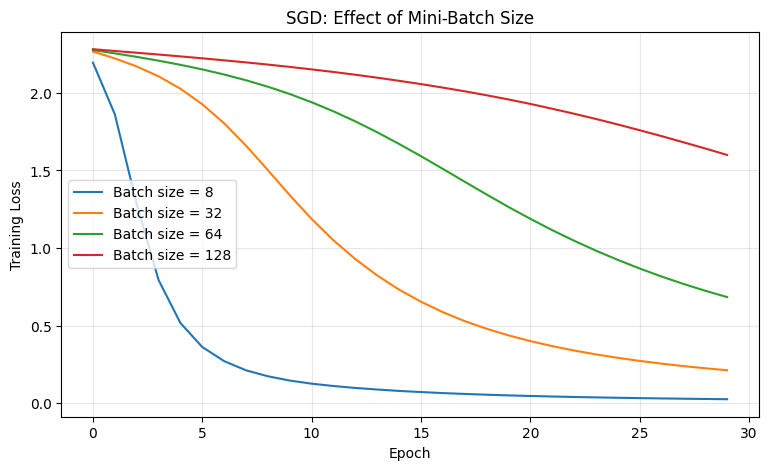

In [ ]:

plt.figure(figsize=(9, 5))

for batch_size, result in batch_results.items():
    plt.plot(
        result["train_loss"],
        label=f"Batch size = {batch_size}"
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("SGD: Effect of Mini-Batch Size")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



# 17. Interpretation Guide

Use your actual results to complete the following observations.

### SGD

- How smooth is its loss curve?
- Does it require more epochs than the adaptive optimizers?
- What happens when the learning rate is increased?

### SGD with Momentum

- Does momentum improve convergence compared with plain SGD?
- Does the loss curve become smoother?
- What happens when $\beta$ is changed?

### RMSprop

- Does adaptive scaling help the model converge quickly?
- How sensitive is it to the learning rate?

### Adam

- Does Adam reach the target accuracy quickly?
- Does its combination of first- and second-moment estimates help?
- Does changing the learning rate significantly affect the result?

### Important

Do **not** assume that one optimizer is always best. The observed result depends on the dataset, architecture, initialization, learning rate, batch size and other hyperparameters.



# 18. Assignment Tasks

### Task 1
Run the main experiment for 50 epochs.

### Task 2
Plot and compare training loss for all four optimizers.

### Task 3
Plot and compare test loss for all four optimizers.

### Task 4
Plot and compare test accuracy for all four optimizers.

### Task 5
Determine which optimizer reaches 95% test accuracy first.

### Task 6
Identify the optimizer with the lowest final test loss.

### Task 7
Identify the optimizer with the highest final test accuracy.

### Task 8
Change the learning rate of SGD and observe the effect.

### Task 9
Change the momentum value of SGD with Momentum to 0.5, 0.9 and 0.99.

### Task 10
Change the learning rate of Adam and compare the results.

### Task 11
Repeat the experiment using batch sizes 8, 32, 64 and 128.

### Task 12
Explain why the same initial model weights should be used when comparing optimizers.

### Task 13
Write a short conclusion based on your experimental observations.



# 19. Viva Questions

1. What is the purpose of an optimization algorithm in neural-network training?
2. What is the difference between Batch Gradient Descent and SGD?
3. Why can SGD updates be noisy?
4. What is the purpose of momentum?
5. What does the parameter $\beta$ represent in Momentum?
6. Why does RMSprop maintain an average of squared gradients?
7. What is the purpose of $\epsilon$ in RMSprop and Adam?
8. What are the first and second moments in Adam?
9. Why does Adam use bias correction?
10. Why can different parameters receive different effective update sizes in RMSprop and Adam?
11. Why should the model architecture remain unchanged during an optimizer comparison?
12. Why should the initial weights be the same?
13. Does the optimizer with the fastest convergence necessarily give the best generalization?
14. What happens when the learning rate is too large?
15. What happens when the learning rate is too small?
16. How does mini-batch size affect SGD?
17. What is the main conceptual difference between Momentum and RMSprop?
18. How does Adam combine ideas from Momentum and RMSprop?



# 20. Conclusion

In this experiment, the same neural network was trained on a **10-class handwritten-digit classification problem** using SGD, SGD with Momentum, RMSprop and Adam.

### Fill in the following after completing the experiment:

- **Fastest convergence:** __________________________
- **Best final test accuracy:** ______________________
- **Lowest final test loss:** ________________________
- **Optimizer most affected by learning rate:** ______
- **Effect of increasing batch size:** _______________